# Market Making Project: 
## Phase 1 Data and Fair Value
Notes:
* TLT is an ETF that tracks long-duration US treasuries (20+ yrs)
    * Highly liquid, rate-sensitive (1% rate move $ \approx $ 17% price move)
    * Spot = 86.72 as of 4-26-2026 (when option data was pulled)
* Need to:
    * Filter option data (vol > 0 & open_int > ~100, check for stale IV) before calibrating Heston
    * Bring in other data sources:
        * TLT underlying data (2-5 yrs) from yahoo finance website (?) **to calculate historical vol**
        * Short rate history (3 month t-bill of Fed Funds rate) from FRED **to calculate short rate history**

---
### Options Data: Downloading and Cleaning

In [77]:
import pandas as pd
from pathlib import Path
import re

# 1. Define the directory containing your files
data_dir = Path("../data/options")

# List to store each processed DataFrame
df_list = []

# Iterate through all CSVs in the target folder
for file_path in data_dir.glob("*.csv"):
    
    # Extract the expiration date using regex
    # Looks for 'exp-' followed by exactly 4 digits, a dash, 2 digits, a dash, 2 digits
    match = re.search(r'exp-(\d{4}-\d{2}-\d{2})', file_path.name)
    
    if match:
        expiration_date = match.group(1)
    else:
        print(f"Warning: Could not find expiration date in {file_path.name}. Skipping.")
        continue
        
    # Read the CSV and trim the bottom row
    df = pd.read_csv(file_path)
    df = df.iloc[:-1].copy() # .copy() prevents SettingWithCopyWarnings later
    
    # Insert the date column (converting to a datetime object for easier time-series analysis later)
    df.insert(0, 'Expiration', pd.to_datetime(expiration_date))

    ### Changing from Side-By-Side to Stacked (downloaded Side-By-Side accidentally) ###
    base_cols = ['Expiration', "Strike"]

    # Isolate the Call columns
    call_cols = ['Type', 'Latest', 'Bid', 'Ask', 'Change', 'Volume', 'Open Int', 'IV', 'Last Trade']
    calls_df = df[base_cols + call_cols].copy()

    # Isolate the Put columns
    put_cols = ['Type.1', 'Latest.1', 'Bid.1', 'Ask.1', 'Change.1', 'Volume.1', 'Open Int.1', 'IV.1', 'Last Trade.1']
    puts_df = df[base_cols + put_cols].copy()

    # Standardize the column names so they stack perfectly
    standard_cols = ['Option_Type', 'Latest', 'Bid', 'Ask', 'Change', 'Volume', 'Open Int', 'IV', 'Last Trade']
    
    calls_df.columns = base_cols + standard_cols
    puts_df.columns = base_cols + standard_cols

    # Stack them
    df_long = pd.concat([calls_df, puts_df], ignore_index=True)
    
    ### Calculating Mid-price, used later
    df_long['Mid'] = (df_long['Bid'] + df_long['Ask']) / 2
    
    # Append to your list
    df_list.append(df_long)

# 6. Concatenate all DataFrames into one massive table
if df_list:
    options_df = pd.concat(df_list, ignore_index=True)

    # Sort the DF so by expiration and strike
    options_df = options_df.sort_values(by = ['Expiration', 'Strike'], ascending = [True, True])

    # Clean the IV column
    options_df['IV'] = options_df['IV'].str.rstrip('%').astype(float) / 100

    # Change Volume and Open Interest to ints (remove commas first, and 0.0 values)
    options_df['Volume'] = (
        options_df['Volume'].astype(str)
            .str.replace(',', '')
            .str.replace('.0', '', regex = False)
    )
    options_df['Volume'] = pd.to_numeric(options_df['Volume'], errors = 'coerce').astype('Int64')
    options_df['Open Int'] = options_df['Open Int'].str.replace(',', '').astype('Int64')

    
    print(f"Successfully combined {len(df_list)} files.")

else:
    print("No files were processed.")

Successfully combined 6 files.


In [83]:
# options_df[options_df['Option_Type'] == 'Call'].iloc[14, :]
# options_df[options_df['Option_Type'] == 'Call'].head(30)

options_df.head()

,Expiration,Strike,Option_Type,Latest,Bid,Ask,Change,Volume,Open Int,IV,Last Trade,Mid
76,2026-05-15,73.0,Call,13.73,13.6,13.75,unch,0,3,0.0000,04/16/26,13.675
116,2026-05-15,73.0,Put,0.01,0.0,0.01,unch,0,793,0.2719,04/21/26,0.005
77,2026-05-15,74.0,Call,12.85,12.6,12.75,unch,0,2,0.0000,NaN,12.675
117,2026-05-15,74.0,Put,0.01,0.0,0.01,unch,345,4286,0.2720,04/24/26,0.005
78,2026-05-15,75.0,Call,11.45,11.6,11.75,unch,0,40,0.0000,04/23/26,11.675


Let's look at some individual expirations to observe the volatility smile/skew. We should be seeing that classic smile pattern. Any variances are likely coming from stale IVs due to low open interest/volatility (they are illiquid).

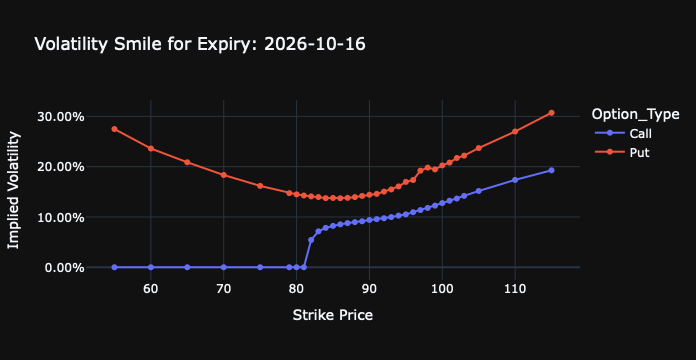

In [44]:
import plotly.express as px

# Choose an expiration
# target_expiry = options_df['Expiration'].max()
target_expiry = pd.to_datetime("2026-05-15")

# Look at options on only that expiry
df_smile = options_df[options_df['Expiration'] == target_expiry]

# Plot IV vs. Strike, coloring by Call vs. Put
fig_smile = px.line(
    df_smile, 
    x='Strike', 
    y='IV', 
    color='Option_Type', 
    markers=True,
    hover_data=['Bid', 'Ask', 'Volume', 'Open Int'], # Crucial for spotting illiquid outliers
    title=f"Volatility Smile for Expiry: {target_expiry.strftime('%Y-%m-%d')}",
    labels={'IV': 'Implied Volatility', 'Strike': 'Strike Price'}
)

fig_smile.update_layout(template="plotly_dark", hovermode="x unified")
fig_smile.update_layout(yaxis=dict(tickformat=".2%"))
fig_smile.show()

Observations:
* Puts show typical vol smile shape, but the shape deteriorates with calls below spot (~86.5)
* Put and Call IV differs significantly (in theory, they should be the same)
* Several calls with 0 IV (looking at options_df, most of these are due to low open interest (OI) or no volume, but there are some liquid instances with 0 IV still)

Notes:
* Reasons why put and call IVs can differ:
    * Demand imbalances (While there are more calls than puts by volume and OI, the puts still cost slighlty more "premium" for the downside protection)
    * Early Exercise premium (Greater for puts than calls, bc you can gain \$K and begin earning interest on it)
    * Numerical instability for ITM options (when deep ITM, the option's value is almost intirely intrinsic, so the vega [sensitivity to vol, timed to time-value of an option] approaches 0 which can lead to numerical instability)
* When calibrating a Heston, we will **use OTM/ATM options only** (OTM typically more liquid, greater vega per $, so more informative regarding vol, and avoids instability issues mentioned above)
    * Between this and some basic filtering to remove stale IVs due to illiquid options, this should fix our issues
    * IV jump ATM when switching from puts to calls: **shouldn't cause an issue, but can revisit if calibration looks off**

In [ ]:
# Is their a demand imbalance?
call_vol = options_df[options_df['Option_Type'] == 'Call']['Volume'].sum()
put_vol = options_df[options_df['Option_Type'] == 'Put']['Volume'].sum()

call_oi = options_df[options_df['Option_Type'] == 'Call']['Open Int'].sum()
put_oi = options_df[options_df['Option_Type'] == 'Put']['Open Int'].sum()

print(f"Call volume: {call_vol}")
print(f"Put volume: {put_vol}")
print(f"Call Open Interest: {call_oi}")
print(f"Call Open Interest: {put_oi}")

Volume and OI demand does not accurately represent skew. We're looking for **pricing differences** where the puts are priced higher than the calls, which is shown by the IVs.

---
### Options Data: Filtering

In [82]:
# Want to see how many options are removed by filtering
print(f"Number of options before cleaning: {options_df.shape[0]}")


Number of options before cleaning: 442
